In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import urllib.request
import zipfile
import time
from numpy.lib import recfunctions

In [72]:
dir_ = 'C:\\obj2\\ad\\lab4'
def download():
    os.makedirs(dir_, exist_ok = True)
    f_name = 'household_power_consumption.zip'
    f_path = os.path.join(dir_, f_name)
    url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00235/household_power_consumption.zip'
    retries = 3
    for i in range(retries):
        try:
            print(f"Спроба завантаження {i + 1} з можливих {retries}")
            with urllib.request.urlopen(url) as response:
                data = response.read()
            if not os.path.exists(f_path):
                with open(f_path, 'wb') as file:
                    file.write(data)
                print(f"Файл {f_name} було завантажено!")
            else:
                print(f"Файл {f_name} вже існує!")
            break
        except urllib.error.URLError as e:
            print(f"Помилка завантаження даних {e}")
            if i == retries - 1:
                print("Не вдалося завантажити файл після кількох спроб")
                return
    try:
        with zipfile.ZipFile(f_path, 'r') as zip:
            f_extracted = zip.namelist()
            for file in f_extracted:
                extracted_path = os.path.join(dir_, file)
                if not os.path.exists(extracted_path):
                    zip.extract(file, dir_)
                    print(f"Файл {file} розпаковано!")
                else:
                    print(f"Файл {file} вже було розпаковано!")
    except zipfile.BadZipFile:
        print("Помилка!")
        return
    print(f"Архів розпаковано у папку: {os.path.abspath(dir_)}")
download()    
                

Спроба завантаження 1 з можливих 3
Файл household_power_consumption.zip вже існує!
Файл household_power_consumption.txt вже було розпаковано!
Архів розпаковано у папку: C:\obj2\ad\lab4


In [73]:
#1 Pandas:
f_path = os.path.join(dir_, 'household_power_consumption.txt')
p_start = time.time()
p_df = pd.read_csv(f_path, sep=';', na_values='?', low_memory=False)
p_df_clean = p_df.dropna(subset=['Global_active_power', 'Date', 'Time']).copy()
p_df_clean.loc[:, 'Global_active_power'] = p_df_clean['Global_active_power'].astype(float)
p_df_clean.loc[:, 'datetime'] = pd.to_datetime(p_df_clean['Date'] + ' ' + p_df_clean['Time'], dayfirst=True)
p_filtered = p_df_clean[p_df_clean['Global_active_power'] > 5]
p_end = time.time()
p_time = round(p_end - p_start, 4)
p_count = len(p_filtered) 

print("Pandas")
print(p_filtered[['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity',
                  'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'datetime']].head(10))
print(f"Час виконання: {p_time}")
print(f"Кількість записів: {p_count}")



Pandas
    Global_active_power  Global_reactive_power  Voltage  Global_intensity  \
1                 5.360                  0.436   233.63              23.0   
2                 5.374                  0.498   233.29              23.0   
3                 5.388                  0.502   233.74              23.0   
11                5.412                  0.470   232.78              23.2   
12                5.224                  0.478   232.99              22.4   
13                5.268                  0.398   232.91              22.6   
20                5.894                  0.000   232.69              25.4   
21                7.706                  0.000   230.98              33.2   
22                7.026                  0.000   232.21              30.6   
23                5.174                  0.000   234.19              22.0   

    Sub_metering_1  Sub_metering_2  Sub_metering_3            datetime  
1              0.0             1.0            16.0 2006-12-16 17:25:00  

In [74]:
# 1 Numpy:
n_start = time.time()
types = [("Date", "U10"), ("Time", "U8"), ("Global_active_power", "float64"), 
         ("Global_reactive_power", "float64"), ("Voltage", "float64"), 
         ("Global_intensity", "float64"), ("Sub_metering_1", "float64"), 
         ("Sub_metering_2", "float64"), ("Sub_metering_3", "float64")]
n_df = np.genfromtxt(f_path, delimiter=';', names=True, dtype=types,
                    missing_values='?', filling_values=np.nan, encoding='utf-8')
mask = np.isfinite(n_df['Global_active_power']) & (n_df['Global_active_power'] > 5)
n_selected = n_df[mask]
n_end = time.time()
n_time = round(n_end - n_start, 4)
n_count = len(n_selected)
print("Numpy")
for i in range(min(5, n_count)):
    print(f"{n_selected[i]['Date']} {n_selected[i]['Time']} - {n_selected[i]['Global_active_power']} кВт")
print(f"Час виконання: {n_time}")
print(f"Кількість записів: {n_count}")

Numpy
16/12/2006 17:25:00 - 5.36 кВт
16/12/2006 17:26:00 - 5.374 кВт
16/12/2006 17:27:00 - 5.388 кВт
16/12/2006 17:35:00 - 5.412 кВт
16/12/2006 17:36:00 - 5.224 кВт
Час виконання: 15.057
Кількість записів: 17547


In [75]:
#2 Pandas:
p_start = time.time()
p_voltage_filt = p_df_clean[p_df_clean['Voltage'].astype(float) > 235]
p_end = time.time()
print(f"Pandas: Voltage > 235 - Час виконання: {p_end - p_start:.4f} секунд ")
print(f"Pandas: Кількість записів: {len(p_voltage_filt)}")
cols_top = ['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity']
cols_bottom = ['Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'datetime']

print("\n" + p_voltage_filt[cols_top].head(10).to_string())
print("\n" + p_voltage_filt[cols_bottom].head(10).to_string())



Pandas: Voltage > 235 - Час виконання: 0.2157 секунд 
Pandas: Кількість записів: 1952491

    Global_active_power  Global_reactive_power  Voltage  Global_intensity
4                 3.666                  0.528   235.68              15.8
5                 3.520                  0.522   235.02              15.0
6                 3.702                  0.520   235.09              15.8
7                 3.700                  0.520   235.22              15.8
14                4.054                  0.422   235.24              17.6
15                3.384                  0.282   237.14              14.2
16                3.270                  0.152   236.73              13.8
17                3.430                  0.156   237.06              14.4
18                3.266                  0.000   237.13              13.8
19                3.728                  0.000   235.84              16.4

    Sub_metering_1  Sub_metering_2  Sub_metering_3            datetime
4              0.0      

In [76]:
# 2 Numpy:
n_df = n_df.copy()
datetime_str = np.char.add(n_df['Date'].astype(str), ' ')
datetime_str = np.char.add(datetime_str, n_df['Time'].astype(str))
n_df = np.lib.recfunctions.append_fields(n_df, 'datetime', datetime_str, usemask=False)
n_start = time.time()
n_df_clean_volt = np.isnan(n_df['Voltage']) == False
n_voltage_filt = n_df[n_df_clean_volt & (n_df['Voltage'] > 235)]
n_end = time.time()
print(f"Numpy: Voltage > 235 - Час виконання: {n_end - n_start:.4f} секунд")
print(f"Numpy: Кількість записів: {len(n_voltage_filt)} ")
cols_top = ['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity']
cols_bottom = ['Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'datetime']

print("\n" + pd.DataFrame(n_voltage_filt[cols_top]).head(10).to_string())
print("\n" + pd.DataFrame(n_voltage_filt[cols_bottom]).head(10).to_string())

Numpy: Voltage > 235 - Час виконання: 0.2700 секунд
Numpy: Кількість записів: 1952491 

   Global_active_power  Global_reactive_power  Voltage  Global_intensity
0                3.666                  0.528   235.68              15.8
1                3.520                  0.522   235.02              15.0
2                3.702                  0.520   235.09              15.8
3                3.700                  0.520   235.22              15.8
4                4.054                  0.422   235.24              17.6
5                3.384                  0.282   237.14              14.2
6                3.270                  0.152   236.73              13.8
7                3.430                  0.156   237.06              14.4
8                3.266                  0.000   237.13              13.8
9                3.728                  0.000   235.84              16.4

   Sub_metering_1  Sub_metering_2  Sub_metering_3             datetime
0             0.0             1.0    

In [77]:
#3 Pandas
p_start = time.time()
p_df3 = p_df_clean.dropna(subset=['Global_intensity', 'Sub_metering_2', 'Sub_metering_3']).copy()
p_df3['Global_intensity'] = p_df3['Global_intensity'].astype(float)
p_df3['Sub_metering_2'] = p_df3['Sub_metering_2'].astype(float)
p_df3['Sub_metering_3'] = p_df3['Sub_metering_3'].astype(float)
p_filt3 = p_df3[(p_df3['Global_intensity'] >= 19) & (p_df3['Global_intensity'] <= 20) & (p_df3['Sub_metering_2'] > p_df3['Sub_metering_3'])]
p_end = time.time()
p_time = round(p_end - p_start, 4)
print(f"Pandas: Час виконання: {p_time}")
print(f"Кількість записів: {len(p_filt3)}")
print(p_filt3[['Global_intensity', 'Sub_metering_2', 'Sub_metering_3']].head(10))

Pandas: Час виконання: 0.3128
Кількість записів: 2509
      Global_intensity  Sub_metering_2  Sub_metering_3
45                19.0            37.0            16.0
460               19.6            13.0             0.0
464               19.6            27.0             0.0
475               19.4            36.0             0.0
476               19.4            35.0             0.0
477               19.4            36.0             0.0
508               19.2            37.0             0.0
944               20.0            38.0             0.0
945               19.0            38.0             0.0
1051              19.2            50.0            17.0


In [78]:
#3 Numpy
n_start = time.time()
n_mask_clean = (np.isnan(n_df['Global_intensity']) == False) & \
             (np.isnan(n_df['Sub_metering_2']) == False) & \
             (np.isnan(n_df['Sub_metering_3']) == False)
n_mask_cond = (n_df['Global_intensity'] >= 19) & \
            (n_df['Global_intensity'] <= 20) & \
            (n_df['Sub_metering_2'] > n_df['Sub_metering_3'])
n_filt3 = n_df[n_mask_clean & n_mask_cond]
n_end = time.time()
n_time = round(n_end - n_start, 4)
print(f"Numpy: Час виконання: {n_time}")
print(f"Кількість записів: {len(n_filt3)}")
print(pd.DataFrame(n_filt3[['Global_intensity', 'Sub_metering_2', 'Sub_metering_3']]).head(10))

Numpy: Час виконання: 0.1264
Кількість записів: 2509
   Global_intensity  Sub_metering_2  Sub_metering_3
0              19.0            37.0            16.0
1              19.6            13.0             0.0
2              19.6            27.0             0.0
3              19.4            36.0             0.0
4              19.4            35.0             0.0
5              19.4            36.0             0.0
6              19.2            37.0             0.0
7              20.0            38.0             0.0
8              19.0            38.0             0.0
9              19.2            50.0            17.0


In [79]:
#4 Pandas
p_start = time.time()
p_df_valid = p_df_clean.dropna(subset=['Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']).copy()
p_sample = p_df_valid.sample(n=500_000, replace=False, random_state=42)
p_sample['Sub_metering_1'] = p_sample['Sub_metering_1'].astype(float)
p_sample['Sub_metering_2'] = p_sample['Sub_metering_2'].astype(float)
p_sample['Sub_metering_3'] = p_sample['Sub_metering_3'].astype(float)
means = p_sample[['Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']].mean()
p_end = time.time()
p_time = round(p_end - p_start, 4)
print(f"Pandas: Час виконання: {p_time}")
print(f"Середні значення для вибірки з 500000 записів: {means}")


Pandas: Час виконання: 0.5061
Середні значення для вибірки з 500000 записів: Sub_metering_1    1.119258
Sub_metering_2    1.308912
Sub_metering_3    6.452950
dtype: float64


In [80]:
#4 Numpy
n_start = time.time()
random_indices = np.random.choice(n_df.shape[0], size=500000, replace=False)
n_sampled = n_df[random_indices]
sub1 = n_sampled['Sub_metering_1']
sub2 = n_sampled['Sub_metering_2']
sub3 = n_sampled['Sub_metering_3']
mean_values = [
    np.nanmean(sub1),
    np.nanmean(sub2),
    np.nanmean(sub3)
]
n_end = time.time()
n_time = round(n_end - n_start, 4)
print(f"Час виконання: {n_time} секунд")
print(f"Середні значення для вибірки з 500000 записів:")
print(f"Sub_metering_1: {mean_values[0]}")
print(f"Sub_metering_2: {mean_values[1]}")
print(f"Sub_metering_3: {mean_values[2]}")


Час виконання: 0.3727 секунд
Середні значення для вибірки з 500000 записів:
Sub_metering_1: 1.115185017136468
Sub_metering_2: 1.3010123884914238
Sub_metering_3: 6.470734315878173


In [81]:
#5 Pandas
p_start = time.time()
p_df['Time'] = pd.to_datetime(p_df['Time'], format='%H:%M:%S', errors='coerce')
p_df['hour'] = p_df['Time'].dt.hour
p_df['minute'] = p_df['Time'].dt.minute
mask_time_and_consumption = (p_df['hour'] >= 18) & (p_df['Global_active_power'] > 6)
p_filt_df = p_df[mask_time_and_consumption]
mask_main_consumption = (p_filt_df['Sub_metering_2'] > p_filt_df[['Sub_metering_1', 'Sub_metering_3']].max(axis=1))
main_consumption_df = p_filt_df[mask_main_consumption]
halfway_index = len(main_consumption_df) // 2
first_half = main_consumption_df.iloc[:halfway_index][::3]
second_half = main_consumption_df.iloc[halfway_index:][::4]
result = pd.concat([first_half, second_half])
p_end = time.time()
p_time = round(p_end - p_start, 4)

print(f"Час виконання: {p_time}")
print(f"Кількість вибраних записів: {len(result)}")
print(result[['Time', 'Global_active_power', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']].head(10))


Час виконання: 10.4645
Кількість вибраних записів: 310
                     Time  Global_active_power  Sub_metering_1  \
41    1900-01-01 18:05:00                6.052             0.0   
44    1900-01-01 18:08:00                6.308             0.0   
17494 1900-01-01 20:58:00                6.386             1.0   
17498 1900-01-01 21:02:00                8.088             1.0   
17501 1900-01-01 21:05:00                7.230             1.0   
17504 1900-01-01 21:08:00                7.352             1.0   
17507 1900-01-01 21:11:00                9.048            34.0   
17510 1900-01-01 21:14:00                9.118            36.0   
17513 1900-01-01 21:17:00                7.040            37.0   
18952 1900-01-01 21:16:00                6.146             0.0   

       Sub_metering_2  Sub_metering_3  
41               37.0            17.0  
44               36.0            17.0  
17494            36.0            17.0  
17498            72.0            17.0  
17501            7

In [84]:
from datetime import datetime
n_start = time.time()
datetimes = np.array([
    datetime.strptime(val[0] if isinstance(val, (list, np.ndarray)) else val, "%d/%m/%Y %H:%M:%S")
    for val in n_df['datetime']
])
gap = np.array(n_df['Global_active_power'])
sub1 = np.array(n_df['Sub_metering_1'])
sub2 = np.array(n_df['Sub_metering_2'])
sub3 = np.array(n_df['Sub_metering_3'])
evening_mask = np.array([dt.hour >= 18 for dt in datetimes])
power_mask = gap > 6
valid_mask = np.isfinite(sub1) & np.isfinite(sub2) & np.isfinite(sub3)
combined_mask = evening_mask & power_mask & valid_mask
filtered_gap = gap[combined_mask]
filtered_sub1 = sub1[combined_mask]
filtered_sub2 = sub2[combined_mask]
filtered_sub3 = sub3[combined_mask]
filtered_datetime = datetimes[combined_mask]
group2_mask = (filtered_sub2 > filtered_sub1) & (filtered_sub2 > filtered_sub3)
dg_gap = filtered_gap[group2_mask]
dg_sub1 = filtered_sub1[group2_mask]
dg_sub2 = filtered_sub2[group2_mask]
dg_sub3 = filtered_sub3[group2_mask]
dg_datetime = filtered_datetime[group2_mask]
result_array = np.column_stack((dg_gap, dg_sub1, dg_sub2, dg_sub3, dg_datetime))
midpoint = len(result_array) // 2
first_half = result_array[:midpoint]
second_half = result_array[midpoint:]
selected_first = first_half[::3]
selected_second = second_half[::4]
final_result = np.concatenate((selected_first, selected_second))
n_end = time.time()
print(f"Numpy: Task 5 - Час виконання: {n_end - n_start:.4f} секунд")
print(f"Кількість знайдених записів: {len(final_result)}")
print(final_result[:10])


Numpy: Task 5 - Час виконання: 50.8400 секунд
Кількість знайдених записів: 310
[[6.052 0.0 37.0 17.0 datetime.datetime(2006, 12, 16, 18, 5)]
 [6.308 0.0 36.0 17.0 datetime.datetime(2006, 12, 16, 18, 8)]
 [6.386 1.0 36.0 17.0 datetime.datetime(2006, 12, 28, 20, 58)]
 [8.088 1.0 72.0 17.0 datetime.datetime(2006, 12, 28, 21, 2)]
 [7.23 1.0 73.0 17.0 datetime.datetime(2006, 12, 28, 21, 5)]
 [7.352 1.0 73.0 17.0 datetime.datetime(2006, 12, 28, 21, 8)]
 [9.048 34.0 71.0 16.0 datetime.datetime(2006, 12, 28, 21, 11)]
 [9.118 36.0 72.0 16.0 datetime.datetime(2006, 12, 28, 21, 14)]
 [7.04 37.0 38.0 17.0 datetime.datetime(2006, 12, 28, 21, 17)]
 [6.146 0.0 70.0 0.0 datetime.datetime(2006, 12, 29, 21, 16)]]


In [12]:
#2 Частина
import matplotlib.pyplot as plt
import seaborn as sns
dir_ = 'C:\\obj2\\ad\\lab4'
def download():
    os.makedirs(dir_, exist_ok = True)
    f_name = 'credit+approval.zip'
    f_path = os.path.join(dir_, f_name)
    url = 'https://archive.ics.uci.edu/static/public/27/credit+approval.zip'
    retries = 3
    for i in range(retries):
        try:
            print(f"Спроба завантаження {i + 1} з можливих {retries}")
            with urllib.request.urlopen(url) as response:
                data = response.read()
            if not os.path.exists(f_path):
                with open(f_path, 'wb') as file:
                    file.write(data)
                print(f"Файл {f_name} було завантажено!")
            else:
                print(f"Файл {f_name} вже існує!")
            break
        except urllib.error.URLError as e:
            print(f"Помилка завантаження даних {e}")
            if i == retries - 1:
                print("Не вдалося завантажити файл після кількох спроб")
                return
    try:
        with zipfile.ZipFile(f_path, 'r') as zip:
            f_extracted = zip.namelist()
            for file in f_extracted:
                extracted_path = os.path.join(dir_, file)
                if not os.path.exists(extracted_path):
                    zip.extract(file, dir_)
                    print(f"Файл {file} розпаковано!")
                else:
                    print(f"Файл {file} вже було розпаковано!")
    except zipfile.BadZipFile:
        print("Помилка!")
        return
    print(f"Архів розпаковано у папку: {os.path.abspath(dir_)}")
download()    
                


Спроба завантаження 1 з можливих 3
Файл credit+approval.zip вже існує!
Файл Index вже було розпаковано!
Файл credit.lisp вже було розпаковано!
Файл credit.names вже було розпаковано!
Файл crx.data вже було розпаковано!
Файл crx.names вже було розпаковано!
Архів розпаковано у папку: C:\obj2\ad\lab4


In [14]:
file_path = os.path.join(dir_, 'crx.data')
columns = ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 'A11', 'A12', 'A13', 'A14', 'Class']
df = pd.read_csv(file_path, header=None, names=columns, na_values='?')
missing_values = df.isnull().sum()
sorted_missing = missing_values[missing_values > 0].sort_values(ascending=False)
print(sorted_missing)

A13    13
A1     12
A6      9
A5      9
A3      6
A4      6
dtype: int64


In [15]:
#1
numeric_cols = df.select_dtypes(include=[np.number]).columns
non_numeric_cols = df.select_dtypes(exclude=[np.number]).columns
df_cleaned = df.copy()
df_cleaned[numeric_cols] = df_cleaned[numeric_cols].fillna(df_cleaned[numeric_cols].mean())
df_cleaned = df_cleaned.dropna(subset=non_numeric_cols)
print("\nКількість пропущених значень після обробки:")
print(df_cleaned.isnull().sum())
print(df)


Кількість пропущених значень після обробки:
A1       0
A2       0
A3       0
A4       0
A5       0
A6       0
A7       0
A8       0
A9       0
A10      0
A11      0
A12      0
A13      0
A14      0
Class    0
dtype: int64
       A1      A2 A3 A4  A5  A6    A7 A8 A9  A10 A11 A12    A13  A14 Class
b   30.83   0.000  u  g   w   v  1.25  t  t    1   f   g  202.0    0     +
a   58.67   4.460  u  g   q   h  3.04  t  t    6   f   g   43.0  560     +
a   24.50   0.500  u  g   q   h  1.50  t  f    0   f   g  280.0  824     +
b   27.83   1.540  u  g   w   v  3.75  t  t    5   t   g  100.0    3     +
b   20.17   5.625  u  g   w   v  1.71  t  f    0   f   s  120.0    0     +
..    ...     ... .. ..  ..  ..   ... .. ..  ...  ..  ..    ...  ...   ...
b   21.08  10.085  y  p   e   h  1.25  f  f    0   f   g  260.0    0     -
a   22.67   0.750  u  g   c   v  2.00  f  t    2   t   g  200.0  394     -
a   25.25  13.500  y  p  ff  ff  2.00  f  t    1   t   g  200.0    1     -
b   17.92   0.205  u  g  aa

In [16]:
#2
def normalize(data):
    return (data - data.min()) / (data.max() - data.min())

def standardize(data):
    return (data - data.mean()) / data.std()
normalized_df = df_cleaned.copy()
standardized_df = df_cleaned.copy()

normalized_df[numeric_cols] = normalize(df_cleaned[numeric_cols])
standardized_df[numeric_cols] = standardize(df_cleaned[numeric_cols])
print("=== Нормовані значення ===")
print(normalized_df[numeric_cols].head(10))

print("\n=== Стандартизовані значення ===")
print(standardized_df[numeric_cols].head(10))


=== Нормовані значення ===
         A1        A2        A7       A10     A13      A14
b  0.271111  0.000000  0.043860  0.014925  0.1010  0.00000
a  0.713016  0.159286  0.106667  0.089552  0.0215  0.00560
a  0.170635  0.017857  0.052632  0.000000  0.1400  0.00824
b  0.223492  0.055000  0.131579  0.074627  0.0500  0.00003
b  0.101905  0.200893  0.060000  0.000000  0.0600  0.00000
b  0.290952  0.142857  0.087719  0.000000  0.1800  0.00000
b  0.308254  0.037143  0.228070  0.000000  0.0820  0.31285
a  0.145556  0.413750  0.001404  0.000000  0.0400  0.01349
b  0.645556  0.017857  0.138947  0.000000  0.0900  0.00314
b  0.456349  0.175536  0.111053  0.000000  0.0260  0.01442

=== Стандартизовані значення ===
         A1        A2        A7       A10       A13       A14
b -0.053522 -0.963565 -0.298240 -0.292957  0.101169 -0.196507
a  2.334653 -0.069554  0.234612  0.730140 -0.817377 -0.089702
a -0.596523 -0.863340 -0.223819 -0.497577  0.551777 -0.039352
b -0.310869 -0.654871  0.445967  0.525521 

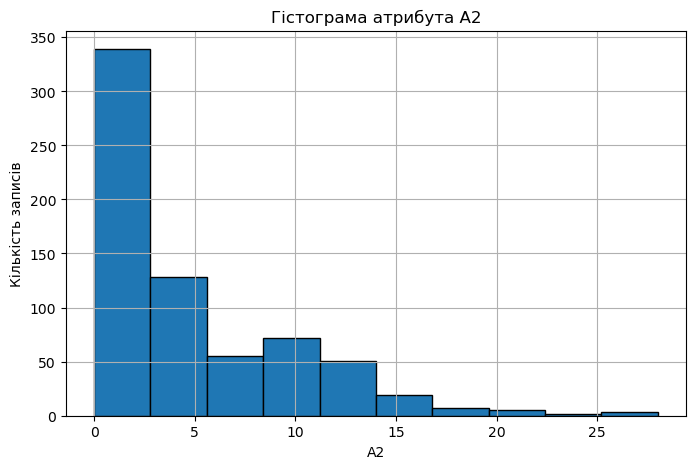

In [17]:
#3
import matplotlib.pyplot as plt
import seaborn as sns
attr = 'A2'
plt.figure(figsize=(8, 5))
plt.hist(df_cleaned[attr], bins=10, edgecolor='black')
plt.title(f'Гістограма атрибута {attr}')
plt.xlabel(attr)
plt.ylabel('Кількість записів')
plt.grid(True)
plt.show()

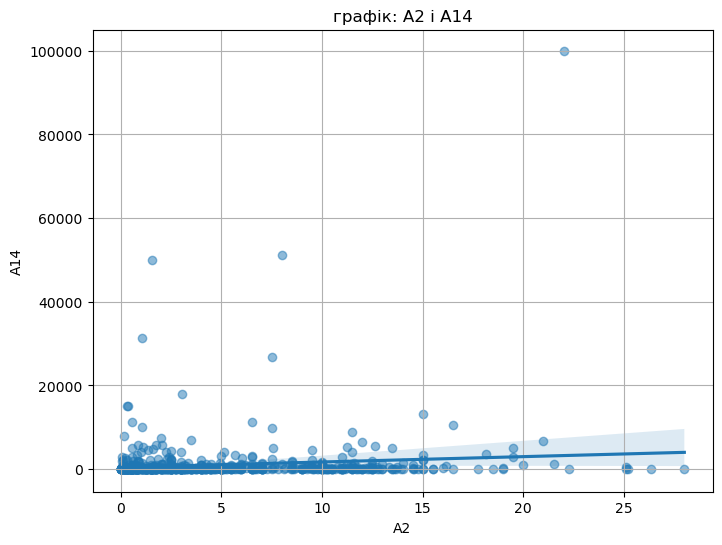

In [18]:
#4
plt.figure(figsize=(8, 6))
sns.regplot(data=df_cleaned, x='A2', y='A14', scatter_kws={'alpha':0.5})
plt.title('графік: A2 і A14')
plt.xlabel('A2')
plt.ylabel('A14')
plt.grid(True)
plt.show()

In [19]:
#5
from scipy.stats import pearsonr, spearmanr
df['A2'] = pd.to_numeric(df['A2'], errors='coerce')
df['A14'] = pd.to_numeric(df['A14'], errors='coerce')
subset = df[['A2', 'A14']].dropna()
pearson_corr, _ = pearsonr(subset['A2'], subset['A14'])
spearman_corr, _ = spearmanr(subset['A2'], subset['A14'])

print(f"Коефіцієнт Пірсона між A2 і A14: {pearson_corr:.3f}")
print(f"Коефіцієнт Спірмена між A2 і A14: {spearman_corr:.3f}")
print(df)

Коефіцієнт Пірсона між A2 і A14: 0.123
Коефіцієнт Спірмена між A2 і A14: 0.106
       A1      A2 A3 A4  A5  A6    A7 A8 A9  A10 A11 A12    A13  A14 Class
b   30.83   0.000  u  g   w   v  1.25  t  t    1   f   g  202.0    0     +
a   58.67   4.460  u  g   q   h  3.04  t  t    6   f   g   43.0  560     +
a   24.50   0.500  u  g   q   h  1.50  t  f    0   f   g  280.0  824     +
b   27.83   1.540  u  g   w   v  3.75  t  t    5   t   g  100.0    3     +
b   20.17   5.625  u  g   w   v  1.71  t  f    0   f   s  120.0    0     +
..    ...     ... .. ..  ..  ..   ... .. ..  ...  ..  ..    ...  ...   ...
b   21.08  10.085  y  p   e   h  1.25  f  f    0   f   g  260.0    0     -
a   22.67   0.750  u  g   c   v  2.00  f  t    2   t   g  200.0  394     -
a   25.25  13.500  y  p  ff  ff  2.00  f  t    1   t   g  200.0    1     -
b   17.92   0.205  u  g  aa   v  0.04  f  f    0   f   g  280.0  750     -
b   35.00   3.375  u  g   c   h  8.29  f  f    0   t   g    0.0    0     -

[690 rows x 15 colum

In [20]:
#6
from sklearn.preprocessing import OneHotEncoder
cat_attr = 'A3'
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded = encoder.fit_transform(df_cleaned[[cat_attr]])
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out([cat_attr]))

df_encoded = pd.concat([df_cleaned.reset_index(drop=True), encoded_df], axis=1).drop(columns=[cat_attr])
print(df_encoded.head())

      A1     A2 A4 A5 A6    A7 A8 A9  A10 A11 A12    A13  A14 Class  A3_l  \
0  30.83  0.000  g  w  v  1.25  t  t    1   f   g  202.0    0     +   0.0   
1  58.67  4.460  g  q  h  3.04  t  t    6   f   g   43.0  560     +   0.0   
2  24.50  0.500  g  q  h  1.50  t  f    0   f   g  280.0  824     +   0.0   
3  27.83  1.540  g  w  v  3.75  t  t    5   t   g  100.0    3     +   0.0   
4  20.17  5.625  g  w  v  1.71  t  f    0   f   s  120.0    0     +   0.0   

   A3_u  A3_y  
0   1.0   0.0  
1   1.0   0.0  
2   1.0   0.0  
3   1.0   0.0  
4   1.0   0.0  


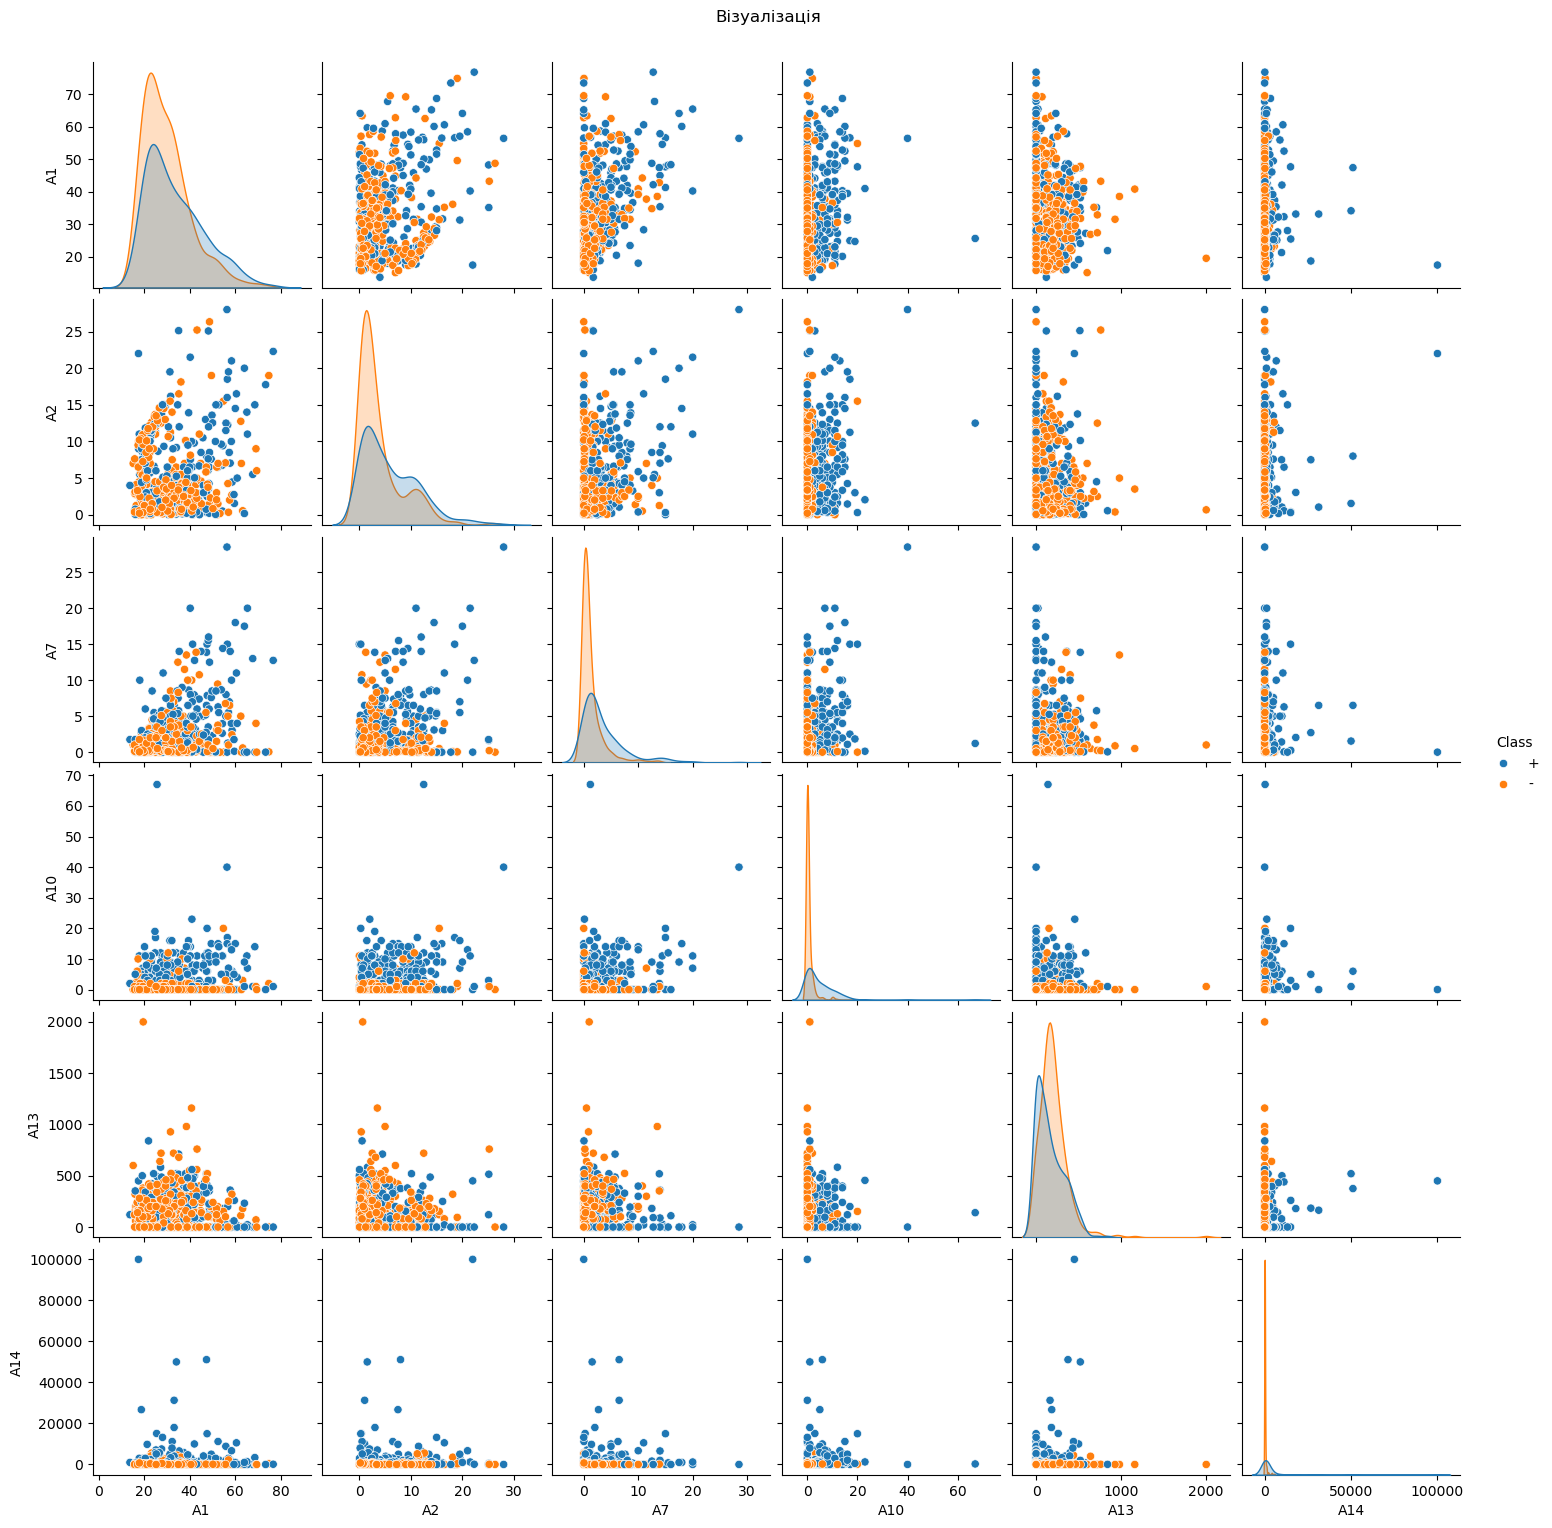

In [24]:
#7
sns.pairplot(df_cleaned[numeric_cols.tolist() + ['Class']], hue='Class', diag_kind='kde')
plt.suptitle("Візуалізація", y=1.02)
plt.show()